In [112]:
! pip install tensorflow

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [114]:
# load the dataset
df1 = pd.read_csv(r"C:\\Users\\sahil\\self project\\AI\\PRAICP-1004-RainfallTS (1)\\rainfall_pred\\rainfall-monthly-highest-daily-total.csv")
df2 = pd.read_csv(r"C:\\Users\\sahil\\self project\\AI\\PRAICP-1004-RainfallTS (1)\\rainfall_pred\\rainfall-monthly-number-of-rain-days.csv")
df3 = pd.read_csv(r"C:\Users\sahil\self project\AI\PRAICP-1004-RainfallTS (1)\rainfall_pred\rainfall-monthly-total.csv")

In [115]:
df1.head()

,month,maximum_rainfall_in_a_day
0,1982-01,36.5
1,1982-02,9.4
2,1982-03,61.7
3,1982-04,45.1
4,1982-05,33.0


In [116]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      462 non-null    object 
 1   maximum_rainfall_in_a_day  462 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.3+ KB


In [117]:
df2.head()

,month,no_of_rainy_days
0,1982-01,10
1,1982-02,5
2,1982-03,11
3,1982-04,14
4,1982-05,10


In [118]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month             462 non-null    object
 1   no_of_rainy_days  462 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 7.3+ KB


In [119]:
df3.head()

,month,total_rainfall
0,1982-01,107.1
1,1982-02,27.8
2,1982-03,160.8
3,1982-04,157.0
4,1982-05,102.2


In [120]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   month           462 non-null    object 
 1   total_rainfall  462 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.3+ KB


In [121]:
# merging the three dataframes 

df = df1.merge(df2, on="month")
df = df.merge(df3, on="month")
df.head()

,month,maximum_rainfall_in_a_day,no_of_rainy_days,total_rainfall
0,1982-01,36.5,10,107.1
1,1982-02,9.4,5,27.8
2,1982-03,61.7,11,160.8
3,1982-04,45.1,14,157.0
4,1982-05,33.0,10,102.2


In [122]:
# convert Date column 

df["month"] = pd.to_datetime(df["month"])

df = df.sort_values("month")

df.set_index("month", inplace=True)

print(df.head())

            maximum_rainfall_in_a_day  no_of_rainy_days  total_rainfall
month                                                                  
1982-01-01                       36.5                10           107.1
1982-02-01                        9.4                 5            27.8
1982-03-01                       61.7                11           160.8
1982-04-01                       45.1                14           157.0
1982-05-01                       33.0                10           102.2


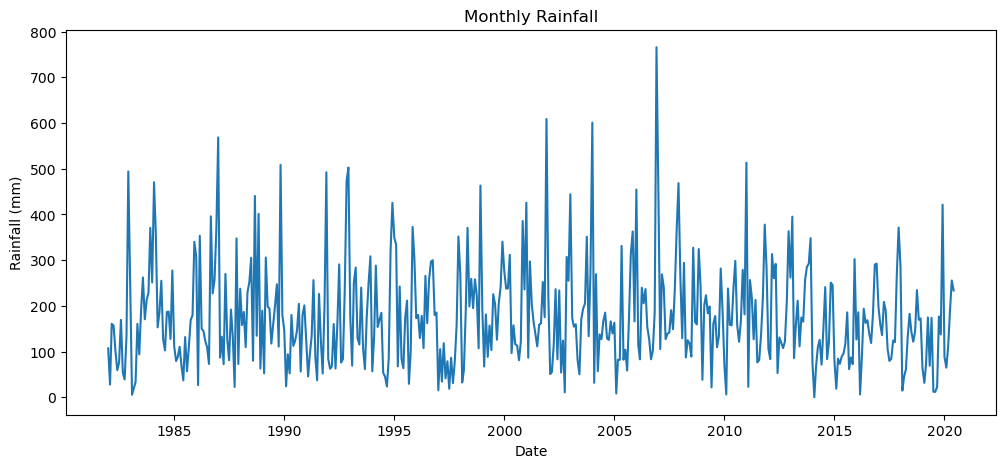

In [123]:
# visualize the data

plt.figure(figsize=(12, 5))

plt.plot(df["total_rainfall"])

plt.title("Monthly Rainfall")

plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")

plt.show()

In [124]:
# normalize the data

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [125]:
# create sequences

def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(seq_length , len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i,2])

    return np.array(X), np.array(y)

seq_length = 24

X, y = create_sequences(scaled_data, seq_length)

In [126]:
# train test split

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [127]:
# model building

model = Sequential()

model.add(LSTM(
    64,
    return_sequences=True,
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")

model.summary()

c:\Users\sahil\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 24, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,497 (197.25 KB)

 Trainable params: 50,497 (197.25 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
# train model

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test))

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0396 - val_loss: 0.0138
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0266 - val_loss: 0.0157
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0250 - val_loss: 0.0162
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0239 - val_loss: 0.0150
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0241 - val_loss: 0.0178
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0247 - val_loss: 0.0140
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0246 - val_loss: 0.0179
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0241 - val_loss: 0.0159
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0246 - val_loss: 0.0185
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0242 - val_loss: 0.0155
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0244 - val_loss: 0.0174
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0

In [129]:
# predict test data

predictions = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


In [130]:
# convert back to original scale

dummy = np.zeros((len(predictions), 3))

dummy[:, 2] = predictions[:, 0]

pred_actual = scaler.inverse_transform(dummy)[:, 2]

In [131]:
dummy2 = np.zeros((len(y_test), 3))

dummy2[:,2] = y_test

y_actual = scaler.inverse_transform(dummy2)[:, 2]

In [132]:
rmse = np.sqrt(mean_squared_error(y_actual, pred_actual))

print("RMSE:", rmse)

RMSE: 111.54660887228798


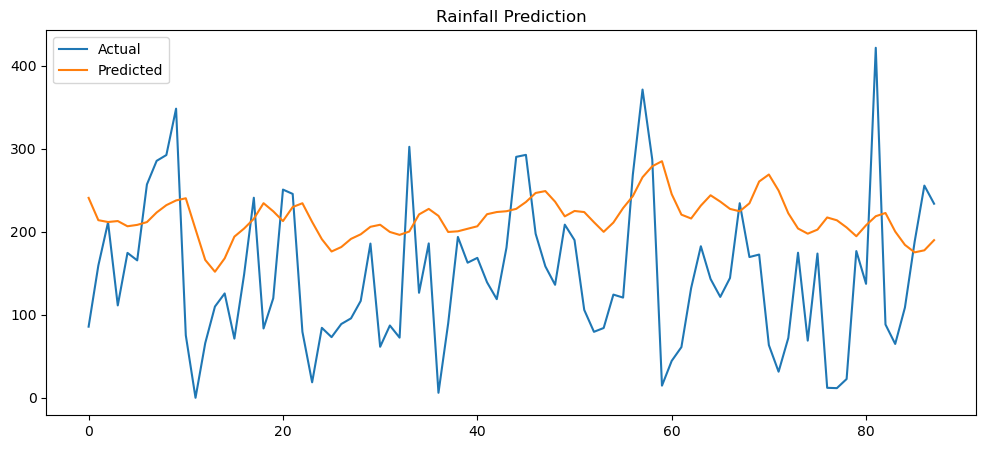

In [133]:
plt.figure(figsize=(12, 5))

plt.plot(y_actual, label="Actual")
plt.plot(pred_actual, label="Predicted")

plt.legend()

plt.title("Rainfall Prediction")

plt.show()

In [139]:
future_steps = 12

last_sequence = scaled_data[-seq_length:]

future_predictions = []

current_sequence = last_sequence.reshape(
    1, seq_length, 3
)

for _ in range(future_steps):

    next_pred = model.predict(current_sequence)[0][0]

    future_predictions.append(next_pred)

    next_row = current_sequence[0, -1, :].copy()

    next_row[2] = next_pred

    current_sequence = np.append(
        current_sequence[:, 1:, :],
        [[next_row]],
        axis=1
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [141]:
dummy_future = np.zeros((future_steps, 3))

dummy_future[:, 2] = future_predictions

future_predictions_actual = scaler.inverse_transform(dummy_future)[:, 2]

print(future_predictions_actual)

[210.14361565 227.29188921 239.33823933 246.6146461  250.24196452
 250.29949282 250.40482827 250.83691812 251.108449   252.01993381
 253.55049259 254.44251225]


In [142]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=future_steps, freq="MS")

forecast_df = pd.DataFrame({
    "month": future_dates,
    "predicted_rainfall": future_predictions_actual
})

print(forecast_df)

        month  predicted_rainfall
0  2020-07-01          210.143616
1  2020-08-01          227.291889
2  2020-09-01          239.338239
3  2020-10-01          246.614646
4  2020-11-01          250.241965
5  2020-12-01          250.299493
6  2021-01-01          250.404828
7  2021-02-01          250.836918
8  2021-03-01          251.108449
9  2021-04-01          252.019934
10 2021-05-01          253.550493
11 2021-06-01          254.442512
